In [1757]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import random
import math

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

In [1758]:
df = pd.read_csv("/Users/juberry/Documents/Code/Machine-Learning/Data/Logistic Regression/train.csv")
df = df.drop_duplicates()
df = df.dropna(subset=["Age"])
df = df.dropna(subset=["Embarked"])

print(df.shape)

(712, 12)


In [1759]:
label = LabelEncoder()
df["Sex"] = label.fit_transform(df["Sex"])
df["Embarked"] = label.fit_transform(df["Embarked"])
X = df[["Pclass", "Sex", "Age", "SibSp", "Parch", "Embarked"]].values
y = df["Survived"].values
print(X[:5])
print(y[:5])

[[ 3.  1. 22.  1.  0.  2.]
 [ 1.  0. 38.  1.  0.  0.]
 [ 3.  0. 26.  0.  0.  2.]
 [ 1.  0. 35.  1.  0.  2.]
 [ 3.  1. 35.  0.  0.  2.]]
[0 1 1 1 0]


In [1760]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)

(569, 6) (143, 6)
(569,) (143,)


In [1761]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [1762]:
def initialize_params(length):
    wi = []
    for i in range(length + 1):
        x = random.gauss(mu=0.0, sigma=0.01)
        wi.append(x)
    return wi

In [1763]:
def prediction(n, w, x, b):
    res = 0
    for i in range(n):
        res += w[i] * x[i]
    res += b
    return res

In [1764]:
def sigmoid(z):
    return 1 / (1 + math.e**(-z))

In [1765]:
def BCE(p, y):
    return -(y * math.log(p) + (1 - y) * math.log(1 - p))

In [1766]:
def derivative(n, w, x, p, y, lr):
    new_w = []
    for i in range(n):
        new_w.append((p-y)*x[i])
    return new_w

def derivative_b(b, lr, p, y):
    return (p - y)

In [1767]:
def update(w, lr, gd):
    res = []
    for i in range(len(gd)):
        res.append(w[i] - lr * gd[i])
    # print(res)
    return res
def update_b(b, lr, gd_b):
    return b - lr * gd_b        

In [1768]:
def accuracy_score(y_pred, y):
    cnt = 0
    for i in range(len(y)):
        if (y_pred[i] == y[i]): 
            cnt += 1
    return cnt / len(y)

In [1769]:
def predict(w, X):
    lw = len(w) - 1 
    # 5
    res = []
    for xi in X:
        # print(">>", xi)
        pred = prediction(lw, w, xi, w[lw])
        p = sigmoid(pred)
        if (p >= 0.5):
            res.append(1)
        else: 
            res.append(0)
        # res.append(sigmoid(pred))
        # print(">>", prediction(lw, w, xi, w[lw]))
    
    return res

In [1770]:
final_w = []

In [1771]:
def logistic_regression(X, y, n_epochs=50, lr = 0.01):
    N, d_plus1 = X.shape
    # print(X.shape)
    thetas = initialize_params(d_plus1)
    thetas_path = [thetas]
    losses = []
    
    for epoch in range(n_epochs):
        for i in range(N):
            random_idx = i
            xi = X[random_idx:random_idx+1]
            yi = y[random_idx:random_idx+1]
            yi = yi[0]
            # print(xi[0])
            # print(yi)
            pred = prediction(d_plus1, thetas, xi[0], thetas[len(thetas)-1])
            # print("pred:",pred)

            p = sigmoid(pred)
            # print("probability: ", p)
            
            bce = BCE(p, yi)
            # print("bce: ", bce)
            
            gd = derivative(d_plus1, thetas, xi[0], p, yi, lr)
            # print("gradient: ", gd)
            
            # print("before:", thetas)
            thetas = update(thetas, lr, gd)
            thetas[len(thetas)-1] = update_b(thetas[len(thetas)-1], lr, derivative_b(thetas[len(thetas)-1], lr, p, yi))
            # print()
                        
            thetas_path.append(thetas)
            losses.append(bce)  
    return thetas_path, losses

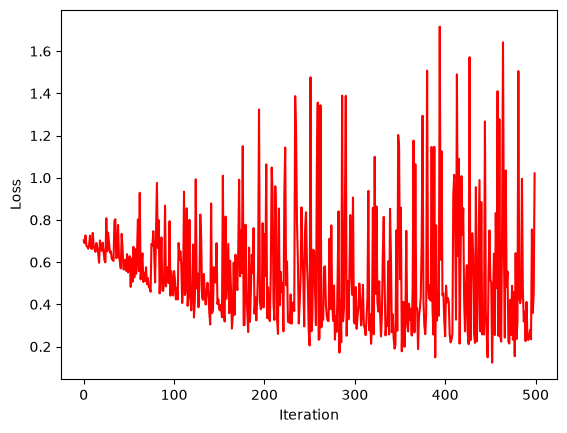

In [1772]:
sgd_theta, losses = logistic_regression(X_train, y_train)
# In loss cho 500 bước đầu
x_axis = list(range(500))
plt.plot(x_axis, losses[:500], color="r")

plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.show()

In [1773]:
def train():
    thetas, loss = logistic_regression(X_train, y_train)

    w = thetas[len(thetas)-1]
    # print("w: ", w)

    y_pred = predict(w, X_test)

    # print(X_test.shape)
    # print(len(y_test), len(y_pred))
    # print(y_test)

    # print('[', end="")
    # for i, val in enumerate(y_pred):
    #     print(val, end="\n" if (i + 1) % 37 == 0 or i == len(y_pred) - 1 else " ")

    accuracy = accuracy_score(y_pred, y_test)

    # print(f"Accuracy: {accuracy*100:.2f}%")
    return accuracy * 100

In [1774]:
maximum = 0
for i in range(50):
    accuracy = train()
    print(f"#{i} ", end="")
    print(f"Accuracy: {accuracy:.2f}%")
    maximum = max(maximum, accuracy)
    
print(f"Max: {maximum:.2f}%")

#0 Accuracy: 81.82%
#1 Accuracy: 81.82%
#2 Accuracy: 81.82%
#3 Accuracy: 81.82%
#4 Accuracy: 81.82%
#5 Accuracy: 81.82%
#6 Accuracy: 81.82%
#7 Accuracy: 81.82%
#8 Accuracy: 81.82%
#9 Accuracy: 81.82%
#10 Accuracy: 81.82%
#11 Accuracy: 81.82%
#12 Accuracy: 81.82%
#13 Accuracy: 81.82%
#14 Accuracy: 81.82%
#15 Accuracy: 81.82%
#16 Accuracy: 81.82%
#17 Accuracy: 81.82%
#18 Accuracy: 81.82%
#19 Accuracy: 81.82%
#20 Accuracy: 81.82%
#21 Accuracy: 81.82%
#22 Accuracy: 81.82%
#23 Accuracy: 81.82%
#24 Accuracy: 81.82%
#25 Accuracy: 81.82%
#26 Accuracy: 81.82%
#27 Accuracy: 81.82%
#28 Accuracy: 81.82%
#29 Accuracy: 81.82%
#30 Accuracy: 81.82%
#31 Accuracy: 81.82%
#32 Accuracy: 81.82%
#33 Accuracy: 81.82%
#34 Accuracy: 81.82%
#35 Accuracy: 81.82%
#36 Accuracy: 81.82%
#37 Accuracy: 81.82%
#38 Accuracy: 81.82%
#39 Accuracy: 81.82%
#40 Accuracy: 81.82%
#41 Accuracy: 81.82%
#42 Accuracy: 81.82%
#43 Accuracy: 81.82%
#44 Accuracy: 81.82%
#45 Accuracy: 81.82%
#46 Accuracy: 81.82%
#47 Accuracy: 81.82%
#4